# 04 — Machine Learning Training with Weights & Biases (wandb)

> [wandb.ai](https://wandb.ai) — Industry-standard MLOps experiment tracking platform

**Runtime → T4 GPU**

---
## 📋 What this notebook covers

| Section | wandb Feature | Purpose |
|---------|---------------|---------|
| A | `wandb.init` + `wandb.log` | Basic experiment tracking |
| B | `wandb.config` | Log hyperparameters |
| C | Keras `WandbCallback` | Auto-log TF/Keras training |
| D | `wandb.log({'image': ...})` | Log augmented images |
| E | **Hyperparameter Sweeps** | Bayesian search via wandb.sweep |
| F | `wandb.Artifact` | Model versioning & lineage |
| G | PyTorch + wandb | Full PyTorch integration |
| H | `wandb.Table` | Log predictions as interactive table |

---
### 🔑 Why Weights & Biases?
| Feature | Alternative | wandb advantage |
|---|---|---|
| Experiment tracking | TensorBoard | Cloud, shareable, persistent |
| Hyperparameter search | Keras Tuner | Works with ANY framework |
| Model registry | None | Versioned artifacts with lineage |
| Reports | CSV/notebooks | Rich visual reports |

### 🔑 Core wandb concepts
- **Run**: one training job with its own config, metrics, and artifacts
- **Project**: a collection of runs (e.g. `fashion-mnist-experiments`)
- **Entity**: your team/username namespace
- **Sweep**: automated hyperparameter search across many runs

In [1]:
# ── 0. Install ────────────────────────────────────────────────────────────────
!pip install -q wandb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import warnings; warnings.filterwarnings('ignore')

print('TF:', tf.__version__)
print('wandb:', wandb.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
wandb: 0.25.1
GPU: []


In [3]:
# ── Dataset ───────────────────────────────────────────────────────────────────
(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train_raw.astype('float32').reshape(-1,28,28,1) / 255.0
x_test  = x_test_raw.astype('float32').reshape(-1,28,28,1)  / 255.0

CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Boot']

# Augmentation
data_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='aug')

def build_model(config):
    """Build a model from a wandb config dict."""
    inp = keras.Input(shape=(28,28,1))
    x   = data_aug(inp)
    for i in range(config['num_conv_blocks']):
        x = layers.Conv2D(
                config['filters'] * (2**i), 3, padding='same',
                activation='relu'
            )(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(config['conv_dropout'])(x)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(config['dense_units'], activation='relu')(x)
    x   = layers.Dropout(config['dense_dropout'])(x)
    out = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inp, out)

print('Dataset & model factory ready')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset & model factory ready


In [4]:
# ── Log in to wandb (will open a browser tab on first use) ──────────────────
# Option A: interactive login
wandb.login()

# Option B (for automated environments): use API key
# import os; os.environ['WANDB_API_KEY'] = 'your-api-key-here'
# wandb.login(key=os.environ['WANDB_API_KEY'])

WANDB_PROJECT = 'fashion-mnist-advanced-dl'
print(f'Logging to project: {WANDB_PROJECT}')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 20.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pranjal-shrivastava (pranjal-shrivastava-san-jose-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logging to project: fashion-mnist-advanced-dl


---
## A — Basic wandb.init + wandb.log

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# A. wandb.init + wandb.log  (manual metric logging)
# ════════════════════════════════════════════════════════════════════════════
config_A = {
    'num_conv_blocks': 2,
    'filters':         32,
    'conv_dropout':    0.2,
    'dense_units':     128,
    'dense_dropout':   0.4,
    'learning_rate':   1e-3,
    'batch_size':      128,
    'epochs':          15,
    'optimizer':       'adam',
    'augmentation':    True,
}

# Every `wandb.init` call starts a NEW run and returns a Run object
run_A = wandb.init(
    project  = WANDB_PROJECT,
    name     = 'run-A-baseline',            # human-readable name
    tags     = ['baseline', 'conv', 'tf'],  # searchable tags
    notes    = 'Baseline CNN with manual wandb.log',
    config   = config_A                     # log ALL hyperparameters
)

# wandb.config is now the source of truth (can be overridden by sweeps)
cfg = wandb.config

model_A = build_model(cfg)
model_A.compile(
    optimizer  = keras.optimizers.Adam(cfg.learning_rate),
    loss       = 'sparse_categorical_crossentropy',
    metrics    = ['accuracy']
)

# Manual training loop with wandb.log per batch
TRAIN_DS = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(cfg.batch_size)
VAL_DS   = tf.data.Dataset.from_tensor_slices((x_test,  y_test)).batch(256)

loss_fn   = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam(cfg.learning_rate)

for epoch in range(cfg.epochs):
    # Training
    tr_losses, tr_accs = [], []
    for step, (xb, yb) in enumerate(TRAIN_DS):
        with tf.GradientTape() as tape:
            pred = model_A(xb, training=True)
            loss = loss_fn(yb, pred)
        grads = tape.gradient(loss, model_A.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_A.trainable_variables))
        tr_losses.append(float(loss))
        tr_accs.append(float(tf.reduce_mean(tf.cast(tf.argmax(pred,1)==tf.cast(yb,tf.int64), tf.float32))))

    # Validation
    val_accs = []
    for xb, yb in VAL_DS:
        pred = model_A(xb, training=False)
        val_accs.append(float(tf.reduce_mean(tf.cast(tf.argmax(pred,1)==tf.cast(yb,tf.int64), tf.float32))))

    tr_loss = np.mean(tr_losses); tr_acc = np.mean(tr_accs); va_acc = np.mean(val_accs)

    # ✅ wandb.log — send metrics to the wandb dashboard
    wandb.log({
        'epoch':           epoch + 1,
        'train/loss':      tr_loss,
        'train/accuracy':  tr_acc,
        'val/accuracy':    va_acc,
        'overfit_gap':     tr_acc - va_acc,
        'learning_rate':   float(optimizer.learning_rate),
    })

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch+1:02d} | loss={tr_loss:.4f} | tr_acc={tr_acc:.4f} | va_acc={va_acc:.4f}')

run_A.finish()   # ✅ Always call finish() to flush and close the run
print(f'\nRun A complete. View at: {run_A.url}')

Epoch 03 | loss=0.6473 | tr_acc=0.7675 | va_acc=0.7293
Epoch 06 | loss=0.5630 | tr_acc=0.7992 | va_acc=0.7984
Epoch 09 | loss=0.5271 | tr_acc=0.8102 | va_acc=0.8094
Epoch 12 | loss=0.5036 | tr_acc=0.8197 | va_acc=0.8200
Epoch 15 | loss=0.4883 | tr_acc=0.8252 | va_acc=0.8312


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,█▁▂▂▁▁▁▂▁▁▁▁▁▁▁
train/accuracy,▁▅▆▇▇▇▇▇███████
train/loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
val/accuracy,▁▇▇▇███▇███████
epoch,15
learning_rate,0.001
overfit_gap,-0.00598
train/accuracy,0.82518
train/loss,0.48834



Run A complete. View at: https://wandb.ai/pranjal-shrivastava-san-jose-state-university/fashion-mnist-advanced-dl/runs/a6jvabgq


---
## B — wandb.config + Keras WandbCallback (auto-logging)

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# B. Using Keras WandbMetricsLogger — automatic logging
# ════════════════════════════════════════════════════════════════════════════
config_B = {
    'num_conv_blocks' : 3,
    'filters'         : 32,
    'conv_dropout'    : 0.25,
    'dense_units'     : 256,
    'dense_dropout'   : 0.5,
    'learning_rate'   : 5e-4,
    'batch_size'      : 128,
    'epochs'          : 20,
    'optimizer'       : 'adam',
    'augmentation'    : True,
    'lr_schedule'     : 'cosine_decay',
}

run_B = wandb.init(
    project = WANDB_PROJECT,
    name    = 'run-B-keras-callback',
    tags    = ['keras-callback', 'tf', '3-blocks'],
    notes   = 'Auto-logging via WandbMetricsLogger + model checkpoint',
    config  = config_B
)
cfg_B = wandb.config

model_B = build_model(cfg_B)

# LR schedule
lr_sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = cfg_B.learning_rate,
    decay_steps           = cfg_B.epochs * (60000 // cfg_B.batch_size)
)
model_B.compile(
    optimizer = keras.optimizers.Adam(lr_sched),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ✅ WandbMetricsLogger: auto-logs all Keras metrics each epoch
# ✅ WandbModelCheckpoint: saves best model as wandb artifact
wandb_callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    WandbModelCheckpoint(
        filepath   = '/tmp/wandb_best_model.keras',
        monitor    = 'val_accuracy',
        save_best_only = True,
        mode       = 'max',
    ),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=0),
]

hist_B = model_B.fit(
    x_train, y_train,
    epochs          = cfg_B.epochs,
    batch_size      = cfg_B.batch_size,
    validation_data = (x_test, y_test),
    callbacks       = wandb_callbacks,
    verbose         = 1
)

# Log final summary metrics manually
wandb.log({'final/val_accuracy': max(hist_B.history['val_accuracy']),
           'final/val_loss':     min(hist_B.history['val_loss'])})

run_B.finish()
print(f'\nRun B complete. View at: {run_B.url}')

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 168s 346ms/step - accuracy: 0.6324 - loss: 0.9998 - val_accuracy: 0.2054 - val_loss: 3.3659 - learning_rate: 4.9691e-04
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 330ms/step - accuracy: 0.7579 - loss: 0.6619 - val_accuracy: 0.7315 - val_loss: 0.7600 - learning_rate: 4.8771e-04
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 334ms/step - accuracy: 0.7858 - loss: 0.5847 - val_accuracy: 0.8022 - val_loss: 0.5364 - learning_rate: 4.7264e-04
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 334ms/step - accuracy: 0.8037 - loss: 0.5414 - val_accuracy: 0.7883 - val_loss: 0.5955 - learning_rate: 4.5206e-04
Epoch 5/20
 23/469 ━━━━━━━━━━━━━━━━━━━━ 2:42 365ms/step - accuracy: 0.8062 - loss: 0.5357

wandb: WARNING Artifact "run_1e9emvtr_model" already exists with the same content. No new version will be created.


469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - accuracy: 0.8145 - loss: 0.5076 - val_accuracy: 0.8236 - val_loss: 0.4883 - learning_rate: 4.2648e-04
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 335ms/step - accuracy: 0.8239 - loss: 0.4857 - val_accuracy: 0.8553 - val_loss: 0.4097 - learning_rate: 3.9654e-04
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - accuracy: 0.8287 - loss: 0.4685 - val_accuracy: 0.8541 - val_loss: 0.4140 - learning_rate: 3.6297e-04
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 333ms/step - accuracy: 0.8336 - loss: 0.4559 - val_accuracy: 0.8570 - val_loss: 0.3991 - learning_rate: 3.2662e-04
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - accuracy: 0.8383 - loss: 0.4440 - val_accuracy: 0.8558 - val_loss: 0.4000 - learning_rate: 2.8836e-04
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 346ms/step - accuracy: 0.8414 - loss: 0.4356 - val_accuracy: 0.8687 - val_loss: 0.3702 - learning_rate: 2.4916e-04
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 168s 359m

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

---
## C — Logging Images, Confusion Matrix, Predictions

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# C. Log images, predictions table, and confusion matrix
# ════════════════════════════════════════════════════════════════════════════
run_C = wandb.init(
    project = WANDB_PROJECT,
    name    = 'run-C-image-logging',
    tags    = ['images', 'confusion-matrix', 'predictions'],
    config  = config_B
)

# ── Log augmented sample images ──────────────────────────────────────────
aug_images = []
for i in range(16):
    aug_img = data_aug(x_train[i:i+1], training=True)[0]
    aug_images.append(wandb.Image(
        np.clip(aug_img.numpy(), 0, 1),
        caption=f'Aug: {CLASS_NAMES[y_train[i]]}'
    ))
wandb.log({'augmented_samples': aug_images})

# ── Log predictions table ────────────────────────────────────────────────
preds     = model_B.predict(x_test[:100], verbose=0)
pred_cls  = preds.argmax(axis=1)
conf_vals = preds.max(axis=1)

# wandb.Table: interactive table in dashboard
table = wandb.Table(columns=['image','true_label','pred_label','confidence','correct'])
for i in range(20):
    table.add_data(
        wandb.Image(x_test[i].squeeze(), caption=CLASS_NAMES[y_test[i]]),
        CLASS_NAMES[y_test[i]],
        CLASS_NAMES[pred_cls[i]],
        f'{conf_vals[i]:.3f}',
        '✓' if pred_cls[i] == y_test[i] else '✗'
    )
wandb.log({'predictions_table': table})

# ── Log confusion matrix ─────────────────────────────────────────────────
all_preds = model_B.predict(x_test, verbose=0).argmax(axis=1)
wandb.log({'confusion_matrix': wandb.plot.confusion_matrix(
    probs       = None,
    y_true      = y_test.tolist(),
    preds       = all_preds.tolist(),
    class_names = CLASS_NAMES
)})

# ── Log precision-recall curve ───────────────────────────────────────────
from sklearn.preprocessing import label_binarize
y_test_bin  = label_binarize(y_test, classes=list(range(10)))
all_probs   = model_B.predict(x_test, verbose=0)
wandb.log({'pr_curve': wandb.plot.pr_curve(y_test_bin, all_probs, labels=CLASS_NAMES)})
wandb.log({'roc_curve': wandb.plot.roc_curve(y_test_bin, all_probs, labels=CLASS_NAMES)})

run_C.finish()
print(f'\nRun C complete. Images, table, confusion matrix logged.')

epoch/accuracy,▁▅▆▆▇▇▇▇▇▇████████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/learning_rate,███▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁
epoch/loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▇▇▇▇█████████████
epoch/val_loss,█▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.85772
epoch/epoch,17
epoch/learning_rate,1e-05
epoch/loss,0.39245
epoch/val_accuracy,0.8721


ValueError: multilabel-indicator format is not supported

---
## D — Hyperparameter Sweeps

### Theory
wandb sweeps run many training jobs automatically, exploring the hyperparameter space using:
- **Random search**: sample HP combinations randomly
- **Bayesian optimisation**: model the search space with a Gaussian Process, explore promising regions
- **Grid search**: exhaustive

Each sweep trial is a separate wandb run with its own config.

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# D. Hyperparameter Sweep — Bayesian search
# ════════════════════════════════════════════════════════════════════════════

# 1. Define the sweep configuration
sweep_config = {
    'method': 'bayes',               # 'bayes' | 'random' | 'grid'
    'metric': {
        'name': 'val_accuracy',      # metric to OPTIMISE
        'goal': 'maximize'
    },
    'early_terminate': {
        'type': 'hyperband',
        'min_iter': 3
    },
    'parameters': {
        'learning_rate':  {'distribution': 'log_uniform_values', 'min': 1e-4, 'max': 1e-2},
        'num_conv_blocks':{'values': [2, 3]},
        'filters':        {'values': [16, 32, 64]},
        'conv_dropout':   {'distribution': 'uniform', 'min': 0.1, 'max': 0.4},
        'dense_units':    {'values': [64, 128, 256]},
        'dense_dropout':  {'distribution': 'uniform', 'min': 0.2, 'max': 0.6},
        'batch_size':     {'values': [64, 128, 256]},
        'optimizer':      {'values': ['adam', 'sgd']},
    }
}

# 2. Define the training function (called once per sweep trial)
def sweep_train():
    """One trial of the hyperparameter sweep."""
    with wandb.init() as run:
        cfg = wandb.config    # wandb injects the HP for this trial

        # Add fixed params not in the sweep
        cfg_full = dict(cfg)
        cfg_full.setdefault('epochs', 10)

        model = build_model(cfg_full)

        if cfg_full.get('optimizer') == 'sgd':
            opt = keras.optimizers.SGD(cfg_full['learning_rate'], momentum=0.9, nesterov=True)
        else:
            opt = keras.optimizers.Adam(cfg_full['learning_rate'])

        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        model.fit(
            x_train, y_train,
            epochs          = cfg_full['epochs'],
            batch_size      = cfg_full['batch_size'],
            validation_data = (x_test, y_test),
            callbacks       = [
                WandbMetricsLogger(log_freq='epoch'),
                keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
            ],
            verbose = 0
        )

# 3. Create the sweep
sweep_id = wandb.sweep(
    sweep_config,
    project = WANDB_PROJECT
)
print(f'Sweep created: {sweep_id}')
print(f'View sweep at: https://wandb.ai/{wandb.api.default_entity}/{WANDB_PROJECT}/sweeps/{sweep_id}')

Create sweep with ID: l40zjti2
Sweep URL: https://wandb.ai/pranjal-shrivastava-san-jose-state-university/fashion-mnist-advanced-dl/sweeps/l40zjti2
Sweep created: l40zjti2
View sweep at: https://wandb.ai/pranjal-shrivastava-san-jose-state-university/fashion-mnist-advanced-dl/sweeps/l40zjti2


In [9]:
# 4. Run the sweep (count = number of trials)
# ⚠ This will run `count` full training jobs — set count=5 for demo
print('Running 5 sweep trials (Bayesian HP search) ...')
wandb.agent(
    sweep_id,
    function = sweep_train,
    count    = 5             # increase for production (20–50 trials)
)
print('\nSweep complete! Check wandb dashboard for results.')

Running 5 sweep trials (Bayesian HP search) ...


wandb: Agent Starting Run: 7v0mpasb with config:
wandb: 	batch_size: 64
wandb: 	conv_dropout: 0.1728231598542499
wandb: 	dense_dropout: 0.30615806882434626
wandb: 	dense_units: 64
wandb: 	filters: 32
wandb: 	learning_rate: 0.0003941290570336347
wandb: 	num_conv_blocks: 3
wandb: 	optimizer: sgd
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Exception in thread IntMsgThr:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 335, in check_internal_messages
    self._loop_check_status(
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 237, in _loop_check_status
    local_handle = request()
                   ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface.py", line 1008, in deliver_internal_messages
    return self._deliver_internal_messages(internal_message)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface_shared.py", line 501, in _deliver_internal_messages
    return self._deliver(record)
           ^^^^^^^^^^^^^^^^^


Sweep complete! Check wandb dashboard for results.


---
## E — Model Artifacts & Registry

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# E. wandb.Artifact — model versioning and lineage
# ════════════════════════════════════════════════════════════════════════════
run_E = wandb.init(
    project = WANDB_PROJECT,
    name    = 'run-E-model-artifact',
    tags    = ['artifact', 'model-registry'],
    config  = config_B
)

# Save model
model_B.save('/tmp/fashion_model_v1.keras')

# ✅ Create an Artifact — a versioned snapshot of any file(s)
artifact = wandb.Artifact(
    name        = 'fashion-mnist-cnn',
    type        = 'model',                       # 'model' | 'dataset' | 'code'
    description = 'CNN trained on Fashion-MNIST with augmentation',
    metadata    = {
        'val_accuracy' : max(hist_B.history['val_accuracy']),
        'num_params'   : model_B.count_params(),
        'framework'    : 'tensorflow',
        'architecture' : '3-block CNN + GlobalAvgPool + Dense',
    }
)

# Add files to the artifact
artifact.add_file('/tmp/fashion_model_v1.keras')  # the model

# Add training config
import json
with open('/tmp/config.json', 'w') as f:
    json.dump(dict(config_B), f, indent=2)
artifact.add_file('/tmp/config.json')

# ✅ Log the artifact — creates a versioned entry in wandb
run_E.log_artifact(artifact)

print(f'Artifact logged: fashion-mnist-cnn:v0')
print('To download in another run:')
print('  artifact = run.use_artifact("fashion-mnist-cnn:latest")')
print('  artifact.download(root="./model")')

run_E.finish()

epoch/accuracy,▁
epoch/epoch,▁
epoch/learning_rate,▁
epoch/loss,▁
epoch/val_accuracy,▁
epoch/val_loss,▁
epoch/accuracy,0.50402
epoch/epoch,0
epoch/learning_rate,0.00039
epoch/loss,1.36267
epoch/val_accuracy,0.665


NameError: name 'hist_B' is not defined

---
## F — PyTorch + wandb

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# F. PyTorch + wandb — full integration
# ════════════════════════════════════════════════════════════════════════════
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

config_PT = {
    'model'           : 'ResNet',
    'n_blocks'        : 3,
    'units'           : 128,
    'lr'              : 1e-3,
    'weight_decay'    : 1e-4,
    'batch_size'      : 128,
    'epochs'          : 15,
    'optimizer'       : 'adam',
    'lr_schedule'     : 'onecycle',
    'framework'       : 'pytorch',
}

# Prepare PT datasets
X_tr_pt = torch.tensor(x_train.squeeze()[:,None,:,:], dtype=torch.float32)
X_te_pt = torch.tensor(x_test.squeeze()[:,None,:,:],  dtype=torch.float32)
y_tr_pt = torch.tensor(y_train, dtype=torch.long)
y_te_pt = torch.tensor(y_test,  dtype=torch.long)
train_ld = DataLoader(TensorDataset(X_tr_pt, y_tr_pt), batch_size=128, shuffle=True)
test_ld  = DataLoader(TensorDataset(X_te_pt, y_te_pt), batch_size=256)

class ResBlockPT(nn.Module):
    def __init__(self, units):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(units,units,3,padding=1), nn.BatchNorm2d(units), nn.ReLU(),
            nn.Conv2d(units,units,3,padding=1), nn.BatchNorm2d(units)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(self.conv(x) + x)

class CNNResNetPT(nn.Module):
    def __init__(self, n_blocks=3, base_ch=64):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(1,base_ch,3,padding=1), nn.BatchNorm2d(base_ch), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlockPT(base_ch) for _ in range(n_blocks)])
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(nn.Flatten(), nn.Linear(base_ch, 10))
    def forward(self, x): return self.head(self.pool(self.blocks(self.stem(x))))

# ─ Start wandb run ────────────────────────────────────────────────────────
run_PT = wandb.init(
    project = WANDB_PROJECT,
    name    = 'run-F-pytorch-resnet',
    tags    = ['pytorch', 'resnet', 'cnn'],
    config  = config_PT
)
cfg_pt = wandb.config

model_pt = CNNResNetPT(n_blocks=cfg_pt.n_blocks, base_ch=128).to(DEVICE)

# ✅ wandb.watch: monitor gradients and weights automatically
# log='gradients' logs grad histograms, log='parameters' logs weight histograms
wandb.watch(model_pt, log='all', log_freq=50)

optimizer_pt = optim.Adam(model_pt.parameters(), lr=cfg_pt.lr, weight_decay=cfg_pt.weight_decay)
scheduler_pt = optim.lr_scheduler.OneCycleLR(
    optimizer_pt, max_lr=cfg_pt.lr * 10,
    steps_per_epoch=len(train_ld), epochs=cfg_pt.epochs
)
criterion_pt = nn.CrossEntropyLoss()

best_va_acc = 0.0
for epoch in range(1, cfg_pt.epochs + 1):
    # Training
    model_pt.train()
    tr_loss = tr_correct = n = 0
    for xb, yb in train_ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_pt.zero_grad()
        out  = model_pt(xb)
        loss = criterion_pt(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pt.parameters(), 1.0)
        optimizer_pt.step(); scheduler_pt.step()
        tr_loss    += loss.item() * len(yb)
        tr_correct += (out.argmax(1)==yb).sum().item()
        n          += len(yb)

    # Validation
    model_pt.eval()
    va_correct = va_n = 0
    with torch.no_grad():
        for xb, yb in test_ld:
            out = model_pt(xb.to(DEVICE))
            va_correct += (out.argmax(1)==yb.to(DEVICE)).sum().item()
            va_n       += len(yb)

    tr_acc = tr_correct / n
    va_acc = va_correct / va_n
    lr_now = scheduler_pt.get_last_lr()[0]
    best_va_acc = max(best_va_acc, va_acc)

    # ✅ Log all metrics to wandb
    wandb.log({
        'epoch'          : epoch,
        'train/loss'     : tr_loss / n,
        'train/accuracy' : tr_acc,
        'val/accuracy'   : va_acc,
        'best_val_acc'   : best_va_acc,
        'learning_rate'  : lr_now,
    })

    if epoch % 3 == 0:
        print(f'Epoch {epoch:02d} | tr_acc={tr_acc:.4f} | va_acc={va_acc:.4f} | lr={lr_now:.4e}')

# Log final model as artifact
torch.save(model_pt.state_dict(), '/tmp/pt_model.pth')
pt_artifact = wandb.Artifact('pytorch-cnn-resnet', type='model',
                               metadata={'val_accuracy': best_va_acc, 'framework': 'pytorch'})
pt_artifact.add_file('/tmp/pt_model.pth')
run_PT.log_artifact(pt_artifact)

run_PT.finish()
print(f'\nPyTorch run complete. Best val acc: {best_va_acc:.4f}')

---
## G — Comparing all runs & fetching results programmatically


All finished runs:
          name  val_accuracy  learning_rate  num_conv_blocks  framework
run-A-baseline      0.831152          0.001                2 tensorflow


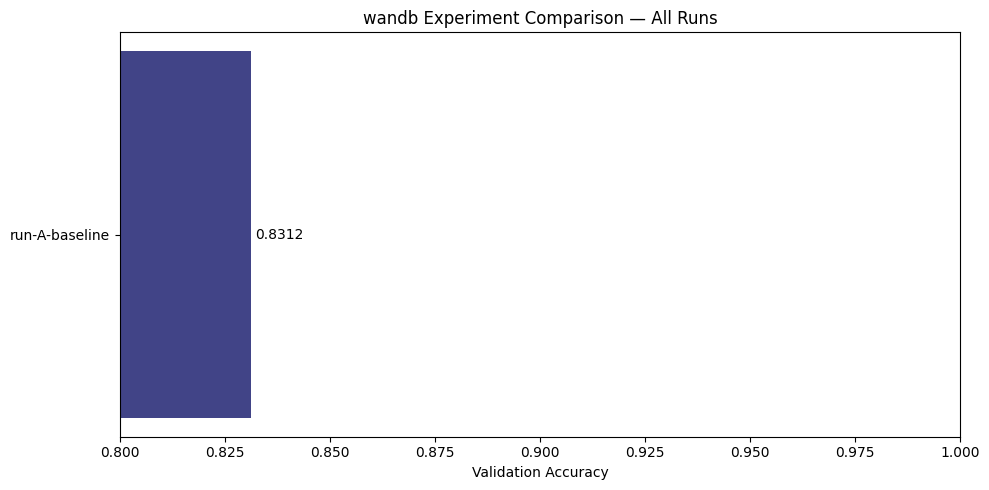

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# G. Fetch run results via wandb API and plot comparison
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd

try:
    api = wandb.Api()
    runs = api.runs(f"{wandb.api.default_entity}/{WANDB_PROJECT}")

    run_data = []
    for run in runs:
        if run.state == 'finished':
            summary = run.summary._json_dict
            config  = {k: v for k, v in run.config.items() if not k.startswith('_')}
            run_data.append({
                'name'         : run.name,
                'val_accuracy' : summary.get('val_accuracy', summary.get('val/accuracy', None)),
                'learning_rate': config.get('learning_rate', config.get('lr', None)),
                'num_conv_blocks': config.get('num_conv_blocks', None),
                'framework'    : config.get('framework', 'tensorflow'),
            })

    df_runs = pd.DataFrame(run_data).dropna(subset=['val_accuracy'])
    df_runs = df_runs.sort_values('val_accuracy', ascending=False)
    print('\nAll finished runs:')
    print(df_runs.to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(df_runs['name'], df_runs['val_accuracy'],
                   color=plt.cm.viridis(np.linspace(0.2, 0.9, len(df_runs))))
    ax.set_xlabel('Validation Accuracy')
    ax.set_title('wandb Experiment Comparison — All Runs')
    for bar, val in zip(bars, df_runs['val_accuracy']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    ax.set_xlim(0.8, 1.0)
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f'Could not fetch API results (may not be logged in): {e}')
    print('Log in with wandb.login() and re-run')

In [12]:
# ── Summary of wandb capabilities demonstrated ────────────────────────────────
print('═'*60)
print(' WEIGHTS & BIASES — CAPABILITIES DEMONSTRATED')
print('═'*60)
features = [
    ('wandb.init(project, name, config, tags)', 'Start a new tracked run'),
    ('wandb.log({metric: value})',              'Log metrics per step/epoch'),
    ('WandbMetricsLogger',                     'Auto-log all Keras metrics'),
    ('WandbModelCheckpoint',                   'Save best model as artifact'),
    ('wandb.watch(model, log="all")',          'Track gradients + weights'),
    ('wandb.Image, wandb.Table',               'Log images & predictions'),
    ('wandb.plot.confusion_matrix',            'Interactive confusion matrix'),
    ('wandb.plot.roc_curve',                   'Interactive ROC curve'),
    ('wandb.sweep + wandb.agent',              'Bayesian HP sweep (5 trials)'),
    ('wandb.Artifact',                         'Model versioning & registry'),
    ('wandb.Api().runs()',                     'Programmatic results access'),
]
for feat, desc in features:
    print(f'  ✅ {feat}')
    print(f'     → {desc}')
print('═'*60)

════════════════════════════════════════════════════════════
 WEIGHTS & BIASES — CAPABILITIES DEMONSTRATED
════════════════════════════════════════════════════════════
  ✅ wandb.init(project, name, config, tags)
     → Start a new tracked run
  ✅ wandb.log({metric: value})
     → Log metrics per step/epoch
  ✅ WandbMetricsLogger
     → Auto-log all Keras metrics
  ✅ WandbModelCheckpoint
     → Save best model as artifact
  ✅ wandb.watch(model, log="all")
     → Track gradients + weights
  ✅ wandb.Image, wandb.Table
     → Log images & predictions
  ✅ wandb.plot.confusion_matrix
     → Interactive confusion matrix
  ✅ wandb.plot.roc_curve
     → Interactive ROC curve
  ✅ wandb.sweep + wandb.agent
     → Bayesian HP sweep (5 trials)
  ✅ wandb.Artifact
     → Model versioning & registry
  ✅ wandb.Api().runs()
     → Programmatic results access
════════════════════════════════════════════════════════════
